# 0 Setup

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent  # cwd is repo root on ironman's server, notebooks/ locally
sys.path.insert(0, str(REPO_ROOT))  # utils.* lives at repo root
sys.path.insert(0, str(REPO_ROOT / 'src'))  # data.* lives at src/

from utils.helpers import Timing
from utils.io_utils import load

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
SAMPLES_DIR = Path(r"D:\eturok\experiment-28\samples")

In [4]:
SAMPLE_ID = 0
LASER_IDX = 55

In [5]:
def load_metadata(sample_dir):
    return {k: v for d in load(sample_dir / 'metadata.jsonl') for k, v in d.items()}

def scene_label(metadata):
    if metadata.get('is_empty_box'): return 'Empty Box'
    objects = metadata.get('objects', {})
    if not objects: return 'Empty Box'
    return ', '.join(name + (f' x{n}' if n > 1 else '') for name, n in objects.items())

# 1 Shifts

In [6]:
def load_raw_vibrations(sample_id: int, samples_dir=SAMPLES_DIR):
    sample_dir = Path(samples_dir) / f"{sample_id:06d}"
    return load(sample_dir / 'vibration/00_raw_vibrations.npy')  # (T, H, W)

def compute_shifts(raw_vibrations: np.ndarray, laser_idx: int, sample_id: int, samples_dir=SAMPLES_DIR, batch_size: int = 256, use_PC=True):
    sample_dir = Path(samples_dir) / f"{sample_id:06d}"
    shifts_path = sample_dir / 'vibration/02_clean_shifts.npy'
    if shifts_path.exists():
        return load(shifts_path)  # (1, L, T, 2)

    from data.pclk import find_frame_translation_PCLKi_cupy
    import cupy as cp

    metadata = load_metadata(sample_dir)
    x, y, w, h = metadata['roi'][laser_idx]
    video = raw_vibrations[:, y:y+h, x:x+w]  # (T, h, w)

    n_frames = video.shape[0]
    all_shifts = cp.empty((n_frames, 2), dtype=cp.float32)
    all_shifts[0] = cp.array([0, 0], dtype=cp.float32)
    n_batches = int(np.ceil((n_frames - 1) / batch_size))
    for i in range(n_batches):
        start = i * batch_size
        end = min((i + 1) * batch_size, n_frames - 1)
        with Timing():
            batch_shifts = find_frame_translation_PCLKi_cupy(video[start : end + 2], use_PC=use_PC)
        all_shifts[start + 1 : end + 2] = batch_shifts

    shifts = cp.asnumpy(cp.cumsum(all_shifts, axis=0))  # (T, 2)
    return shifts[None, None]                           # (1, 1, T, 2)

In [7]:
def plot_shifts(shifts, sample_id: int, laser_idx: int | None, samples_dir=SAMPLES_DIR, title=None):
    sample_dir = Path(samples_dir) / f"{sample_id:06d}"
    metadata = load_metadata(sample_dir)
    fps = int(metadata['fps'])  # shifts are sampled at the camera's fps, not a freq bin rate

    laser_shifts = shifts[0].mean(axis=0) if laser_idx is None else shifts[0, laser_idx]  # (T, 2)
    x_shifts = laser_shifts[:, 0]
    y_shifts = laser_shifts[:, 1]
    t = np.arange(len(x_shifts)) / fps  # frame index -> seconds

    laser_label = f'laser={laser_idx or "avg"}'
    fig, axs = plt.subplots(2, 1, figsize=(16, 6))
    fig.suptitle(title or f"{scene_label(metadata)} Shifts {laser_label} speaker={metadata['speaker']}")

    axs[0].plot(t, x_shifts)
    axs[0].set_title('x shift')
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Shift (pixels)')

    axs[1].plot(t, y_shifts, color='orange')
    axs[1].set_title('y shift')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Shift (pixels)')

    fig.tight_layout()
    # return fig, axs

# 2 FFT

In [8]:
def compute_fft(shifts, sample_id: int, samples_dir=SAMPLES_DIR):
    sample_dir = Path(samples_dir) / f"{sample_id:06d}"
    fft_path = sample_dir / 'vibration/03_fft.npz'
    if fft_path.exists():
        fft, freqs = load(fft_path, keys=['fft', 'freqs'])  # fft: (1, L, F, 2), freqs: (F,)
        return fft, freqs

    from data.vibrate import get_fft_shifts, MIN_FREQ, MAX_FREQ
    metadata = load_metadata(sample_dir)
    fps = int(metadata['fps'])
    fft, freqs, n_samples = get_fft_shifts(shifts, fps, MIN_FREQ, MAX_FREQ)  # (B,L,T,2) -> (B,L,F,2), (F,)
    return fft, freqs

In [9]:
def plot_fft_magnitude(fft, freqs, sample_id: int, laser_idx: int | None, samples_dir=SAMPLES_DIR, title=None):
    sample_dir = Path(samples_dir) / f"{sample_id:06d}"
    metadata = load_metadata(sample_dir)

    mag = np.abs(fft[0])  # (L, F, 2)
    mag = mag.mean(axis=0) if laser_idx is None else mag[laser_idx]  # (F, 2)
    mag_x, mag_y = mag[:, 0], mag[:, 1]

    laser_label = 'avg over lasers' if laser_idx is None else f'laser={laser_idx}'
    fig, axs = plt.subplots(2, 1, figsize=(16, 6))
    fig.suptitle(title or f"{scene_label(metadata)} FFT Magnitude {laser_label} speaker={metadata['speaker']}")

    axs[0].plot(freqs, mag_x)
    axs[0].set_title('x shift')
    axs[0].set_xlabel('Frequency (Hz)')
    axs[0].set_ylabel('Magnitude')

    axs[1].plot(freqs, mag_y, color='orange')
    axs[1].set_title('y shift')
    axs[1].set_xlabel('Frequency (Hz)')
    axs[1].set_ylabel('Magnitude')

    fig.tight_layout()
    # return fig, axs

# 3 Compare

In [10]:
scene = scene_label(load_metadata(Path(SAMPLES_DIR) / f"{SAMPLE_ID:06d}"))
raw_vibrations = load_raw_vibrations(SAMPLE_ID)
raw_vibrations.shape

(3250, 300, 1056)

134.66 ms
 42.87 ms
 42.79 ms
 42.15 ms
 42.40 ms
 42.80 ms
 42.91 ms
 43.01 ms
 42.52 ms
 43.08 ms
 42.85 ms
 42.53 ms
 37.72 ms


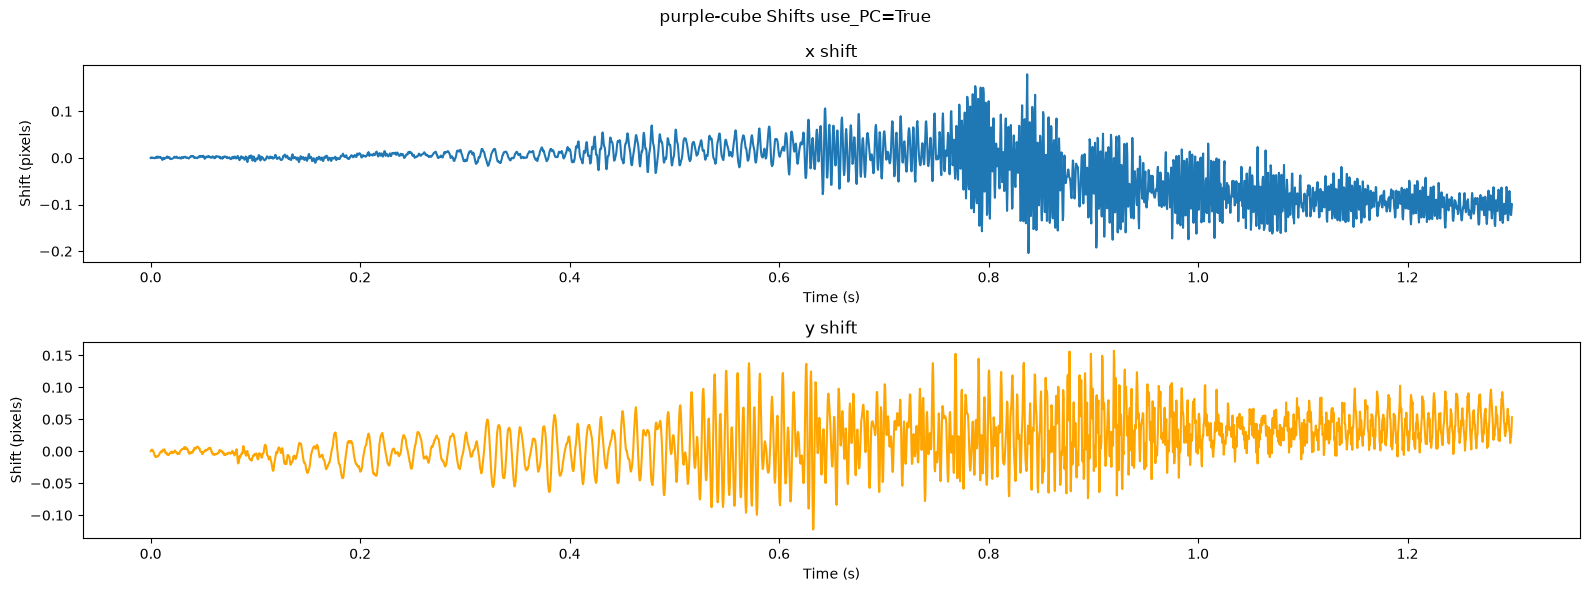

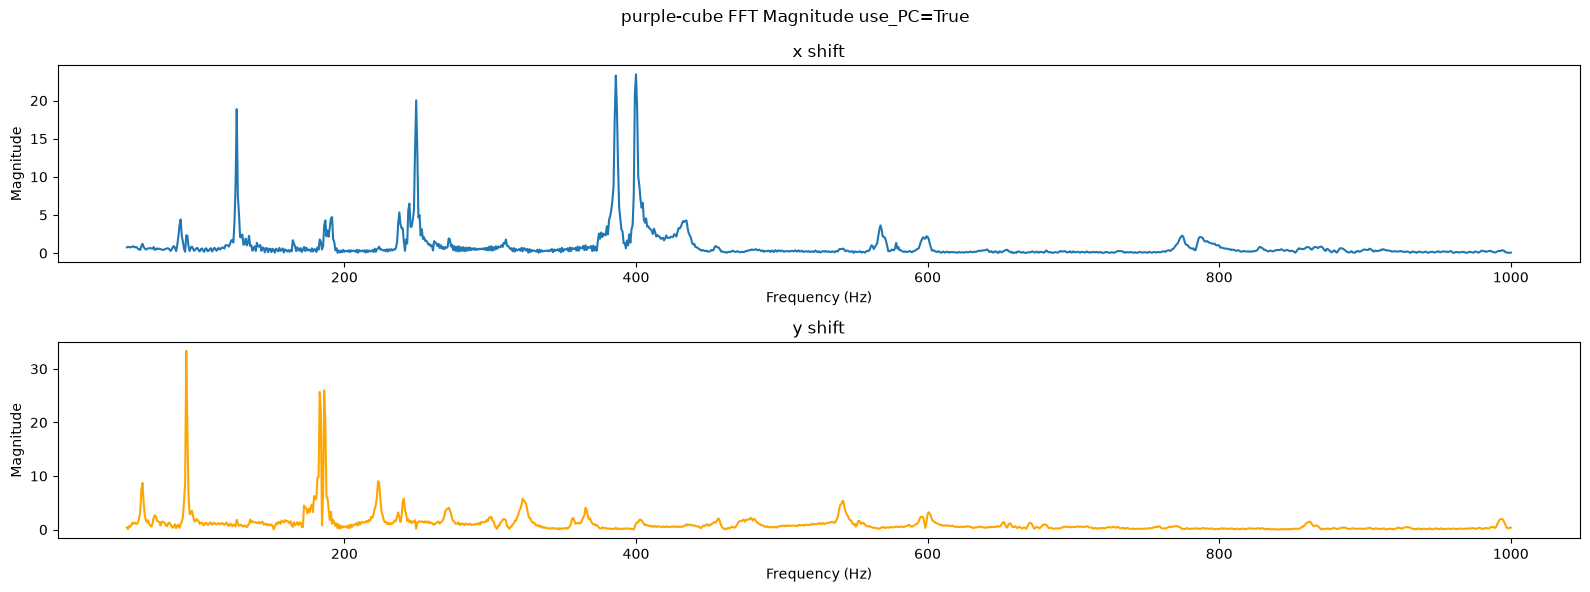

In [11]:
use_PC = True
shifts_pc = compute_shifts(raw_vibrations, LASER_IDX or 0, SAMPLE_ID, use_PC=use_PC)  # (1, 1, T, 2)
plot_shifts(shifts_pc, SAMPLE_ID, 0, title=f"{scene} Shifts use_PC={use_PC}")
plot_fft_magnitude(*compute_fft(shifts_pc, SAMPLE_ID), SAMPLE_ID, 0, title=f"{scene} FFT Magnitude use_PC={use_PC}")

  5.67 ms
  5.00 ms
  4.79 ms
  4.76 ms
  5.45 ms
  5.14 ms
  5.00 ms
  5.41 ms
  4.93 ms
  4.82 ms
  4.95 ms
  4.80 ms
  4.42 ms


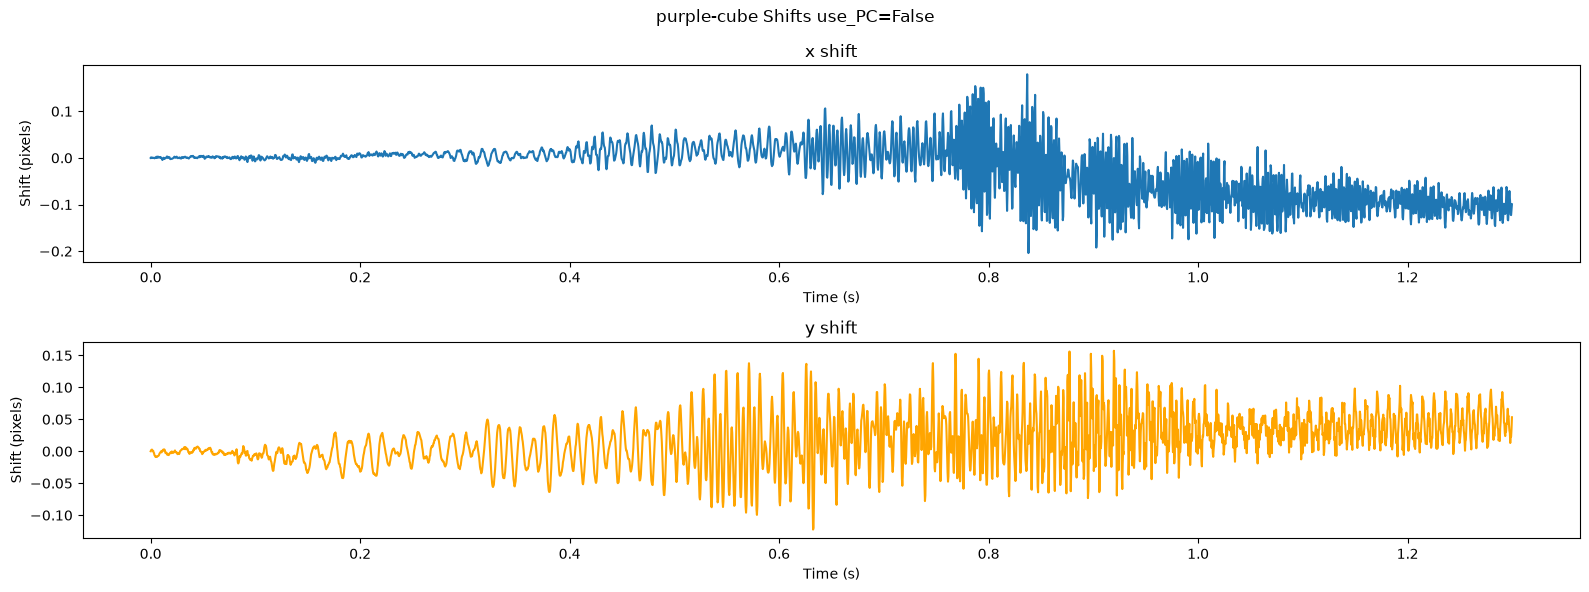

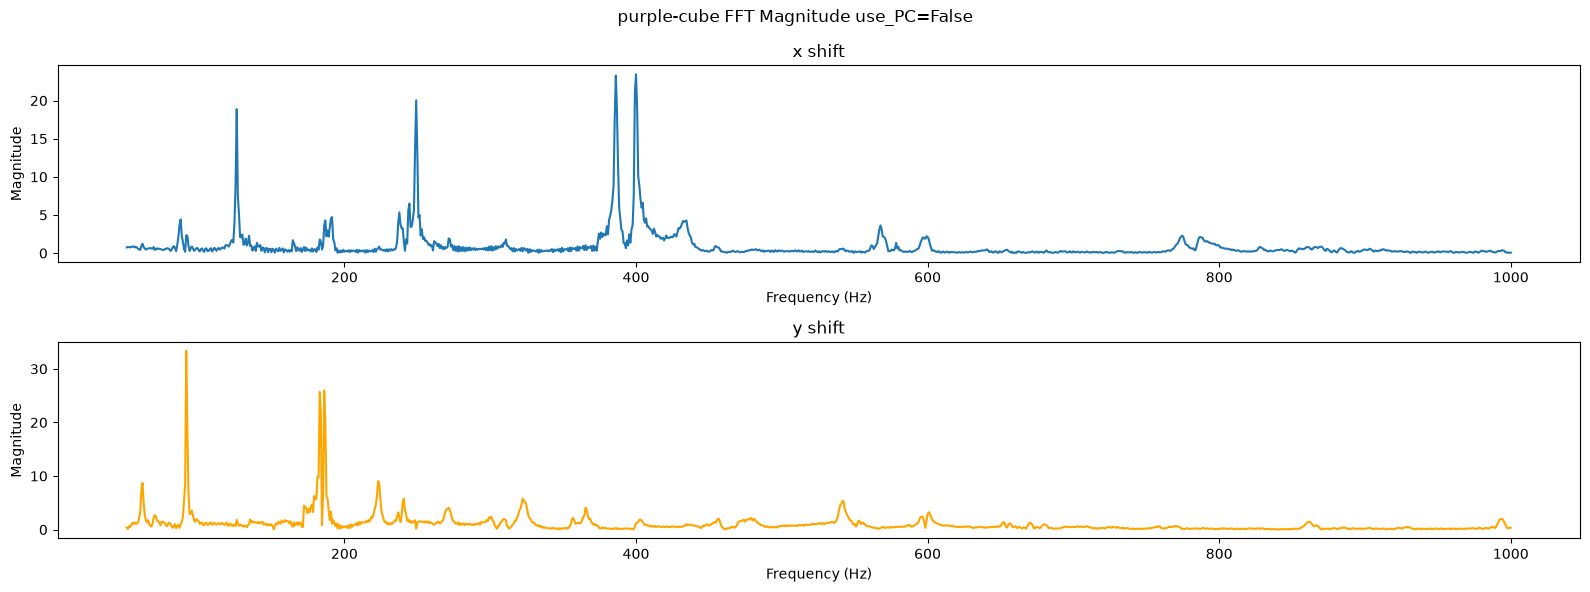

In [12]:
use_PC = False
shifts_no_pc = compute_shifts(raw_vibrations, LASER_IDX or 0, SAMPLE_ID, use_PC=use_PC)  # (1, 1, T, 2)
plot_shifts(shifts_no_pc, SAMPLE_ID, 0, title=f"{scene} Shifts use_PC={use_PC}")
plot_fft_magnitude(*compute_fft(shifts_no_pc, SAMPLE_ID), SAMPLE_ID, 0, title=f"{scene} FFT Magnitude use_PC={use_PC}")

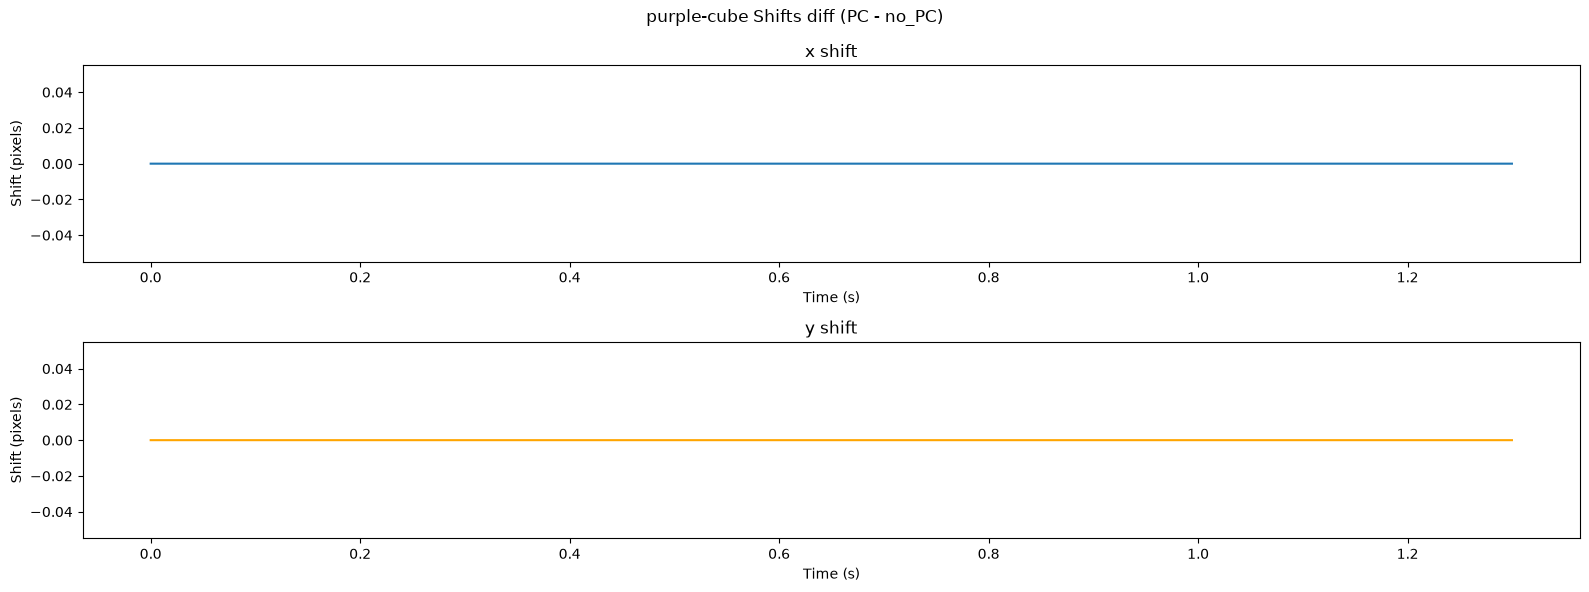

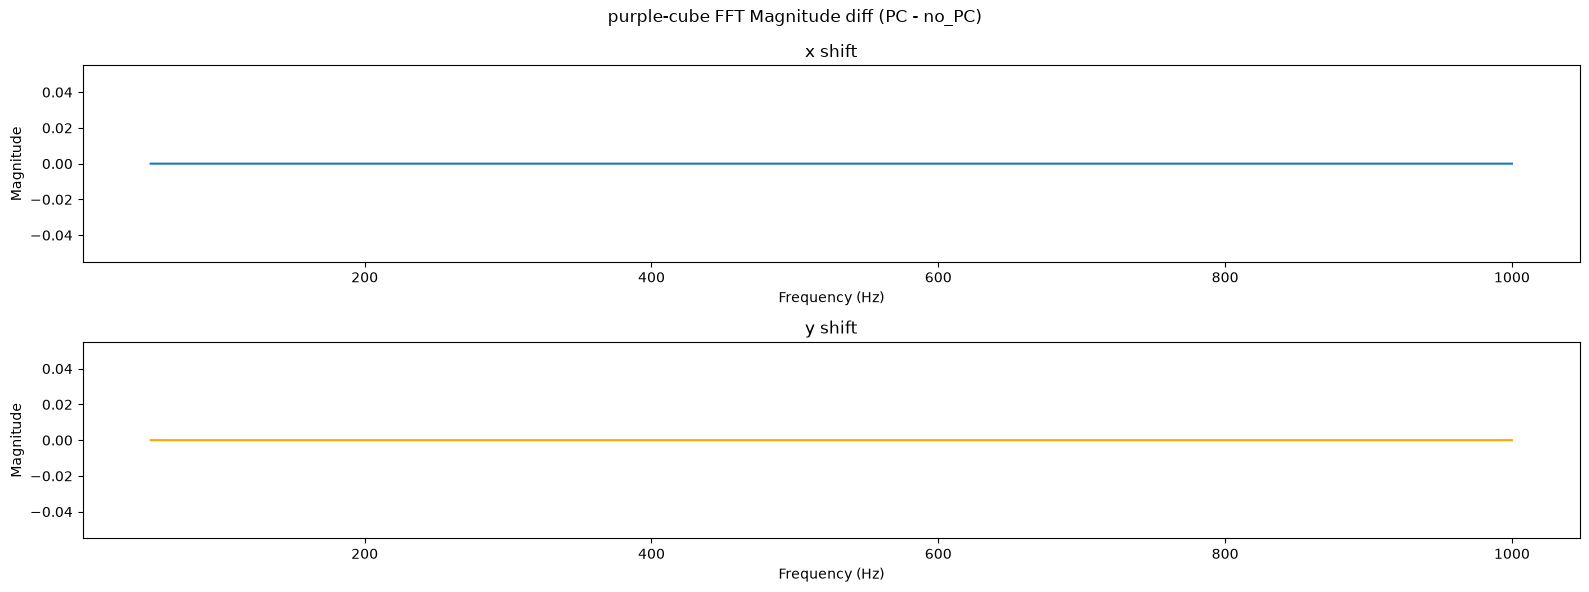

In [13]:
shifts_diff = shifts_pc - shifts_no_pc  # (1, 1, T, 2)
fft_diff, freqs_diff = compute_fft(shifts_diff, SAMPLE_ID)

assert np.isclose(shifts_diff.sum(), 0)
assert np.isclose(fft_diff.sum(), 0)

plot_shifts(shifts_diff, SAMPLE_ID, 0, title=f"{scene} Shifts diff (PC - no_PC)")
plot_fft_magnitude(fft_diff, freqs_diff, SAMPLE_ID, 0, title=f"{scene} FFT Magnitude diff (PC - no_PC)")